In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
for item in cl.get_platforms():
    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

C:\Anaconda3\lib\site-packages\pytools\persistent_dict.py:59: UserWarning: pytools.persistent_dict: unable to import 'siphash24.siphash13', falling back to hashlib.sha256
  warn("pytools.persistent_dict: unable to import 'siphash24.siphash13', "


[<pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x1d564526e60>]
[<pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x1d56447bce0>]
[<pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x1d56447a8e0>]
[]
No cuda device found. Check your pycuda installation.
('ocl', 0, 0, <pyopencl.Platform 'Intel(R) OpenCL Graphics' at 0x1d55f8865d0>, <pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x1d564526e60>, <reikna.cluda.ocl.Thread object at 0x000001D567E4CAC0>, 64)
('ocl', 1, 0, <pyopencl.Platform 'Intel(R) OpenCL' at 0x1d5663fdc40>, <pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x1d56447bce0>, <reikna.cluda.ocl.Thread object at 0x000001D567EDEC40>, 1)
('ocl', 2, 0, <pyopencl.Platform 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x1d5663fe360>, <pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'In

(7676,)


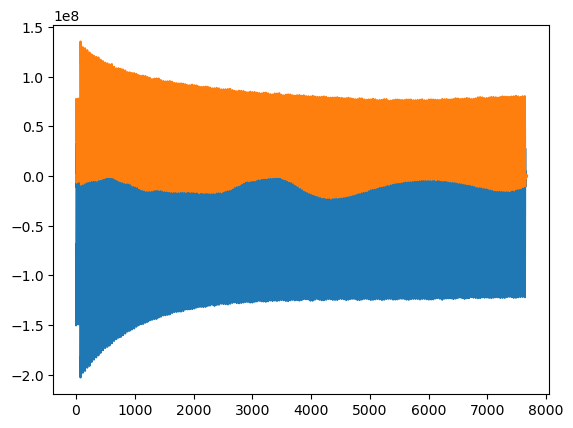

(202, 38)


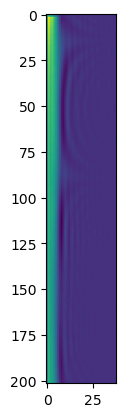

C:\Anaconda3\lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Anaconda3\lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


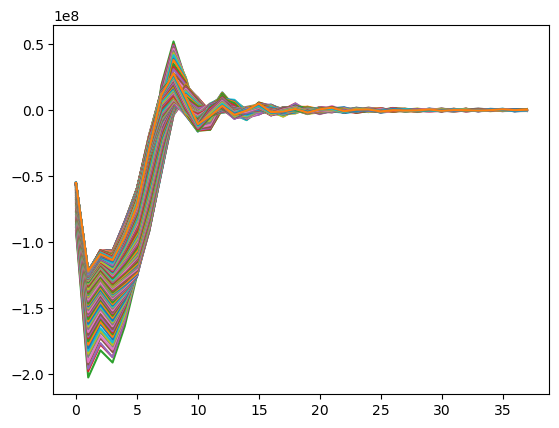

In [23]:
raw_path = "TestData/BrukerPV360/UTE2d"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]

print(np.shape(FID))

plt.figure()
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show()

NPro = a.dataset['PARAM']['method'][0]['NPro']

FID_2d = np.reshape(FID, [NPro, -1])
print(np.shape(FID_2d))

plt.figure()
plt.imshow(np.real(FID_2d))
plt.imshow(np.imag(FID_2d))
plt.show()

plt.figure()
for ro in FID_2d:
    plt.plot(ro)
plt.show()

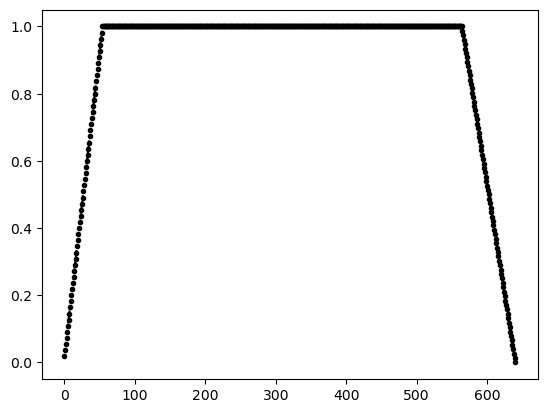

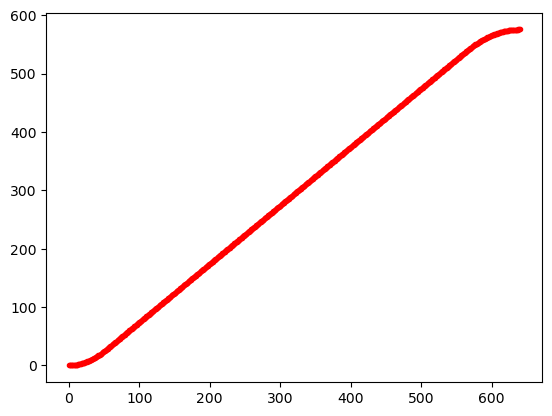

2.0 10.0


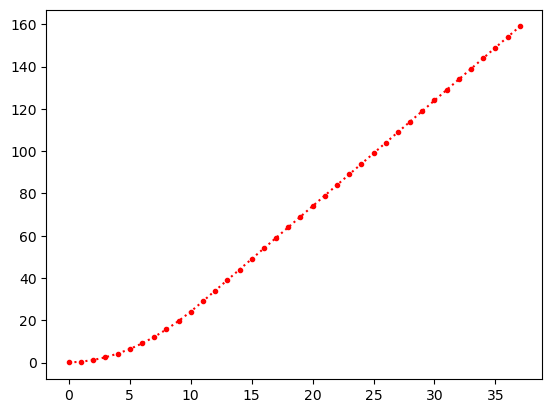

In [3]:
radial = (a.dataset['PARAM']['method'][0]['GradShape2'])
traj_radial = np.cumsum(radial)


plt.figure()
plt.plot(radial, c= "black", marker='.', linestyle=':')
plt.show()

plt.figure()
plt.plot(traj_radial, c= "red", marker='.', linestyle=':')
plt.show()

gradRes_us = a.dataset['PARAM']['method'][0]['GradRes'] * 1000
roRes_us = 1e6/a.dataset['PARAM']['method'][0]['PVM_EffSWh']

print(gradRes_us, roRes_us)
traj_cal = traj_radial[::int(roRes_us/gradRes_us)][:np.shape(FID_2d)[1]]
plt.figure()
plt.plot(traj_cal, c= "red", marker='.', linestyle=':')
plt.show()


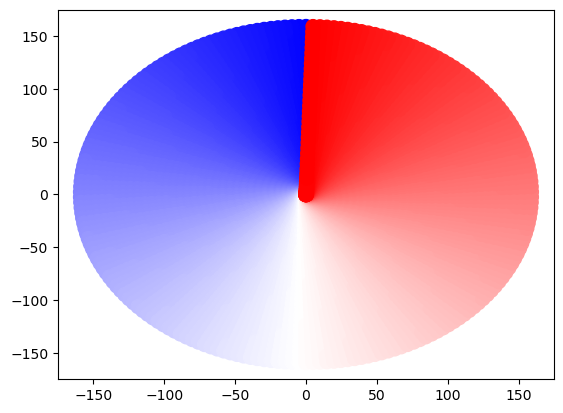

In [19]:
om = []
for i in range(NPro):
    om.append(traj_cal * np.exp((i/NPro+0.25)*1j*2*np.pi))
om = np.asarray(om).flatten()

plt.figure()
plt.scatter(om.real, om.imag, c=(range(len(om))), s=100, cmap='bwr')
plt.show()

rad_traj = np.asarray([[x.real,x.imag] for x in om])

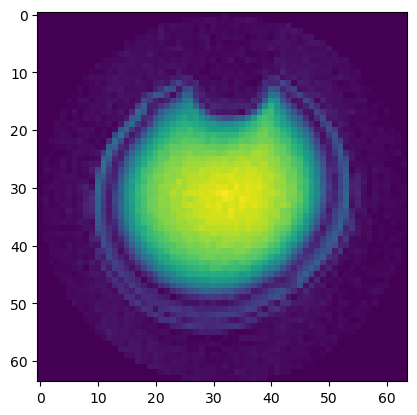

In [20]:
bruker_data = a.dataset['DATA']['2dseq']

img_shape = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = a.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.viridis)
plt.show()


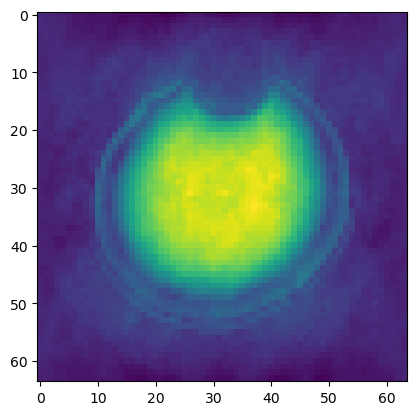

In [21]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(rad_traj, Nd, Kd, Jd)

bruker_data = np.reshape(bruker_data, img_shape)
y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()


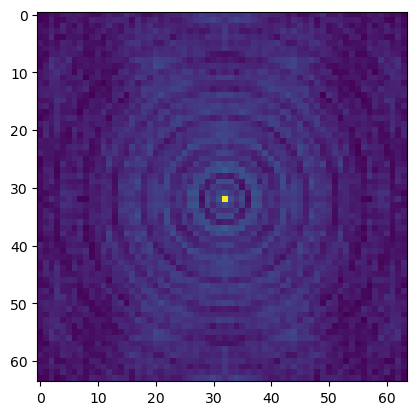

In [22]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(rad_traj, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, -1), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()
